# Differential Expression in scRNA-seq

Now that we can identify cell types (Notebook 1) and handle batch effects (Notebook 2), the next question in almost every project is: **what genes are different between groups?**

Differential expression (DE) analysis addresses this at two scales:

- **Between cell types** — what genes define each cluster? These are marker genes.
- **Between conditions** — within a known cell type, what changes between treated and untreated, healthy and diseased, or any other comparison?

At every stage we will ask:
- What is the statistical question being asked?
- What assumptions does this test make?
- How do I read and interpret the output?
- What would a false positive look like here?

---
# 1. Setup
---

We use `pbmc3k_processed()`, which is the fully analyzed version of the PBMC3k dataset with pre-computed cell type labels. This lets us focus on DE rather than repeating the pipeline from Notebook 1.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy.sparse as sp

sc.settings.verbosity = 1
sc.set_figure_params(dpi=80)

adata = sc.datasets.pbmc3k_processed()

print(adata)
print("\nCell types:")
print(adata.obs['louvain'].value_counts())

  0%|          | 0.00/23.5M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

Cell types:
louvain
CD4 T cells          1144
CD14+ Monocytes       480
B cells               342
CD8 T cells           316
NK cells              154
FCGR3A+ Monocytes     150
Dendritic cells        37
Megakaryocytes         15
Name: count, dtype: int64


---
# 2. What is Differential Expression?
---

For each gene, DE analysis asks: is the mean expression in group A significantly different from group B?

## Key concepts

**Log fold change (LFC)** — the magnitude of the difference in log-normalized expression. An LFC of 1 means expression is roughly doubled in one group.

**P-value** — the probability of seeing a difference this large by chance under the null hypothesis.

**Adjusted p-value** — because we test thousands of genes simultaneously, most raw p-values will produce false positives by chance. Multiple testing correction (e.g. Benjamini-Hochberg) adjusts p-values to control the false discovery rate.

## What to report

Statistical significance alone is not sufficient. A gene can be highly significant with a negligible fold change if your sample is large enough. Always look at both:
- Effect size (LFC)
- Statistical significance (adjusted p-value)

A common threshold: |LFC| > 0.5 and adjusted p < 0.05.

---
# 3. Cell-Type Marker Genes
---

The first DE question: what genes define each cell type compared to all others?

Scanpy's `rank_genes_groups` tests each gene in each cluster against the rest of the dataset. We use the Wilcoxon rank-sum test here, which is non-parametric and robust to the skewed distributions typical of single-cell data.

The result: a ranked list of marker genes per cluster, ordered by how specific and highly expressed they are in that group.

In [2]:
# Rank genes per cell type (one-vs-rest Wilcoxon test)
sc.tl.rank_genes_groups(adata, groupby='louvain', method='wilcoxon')

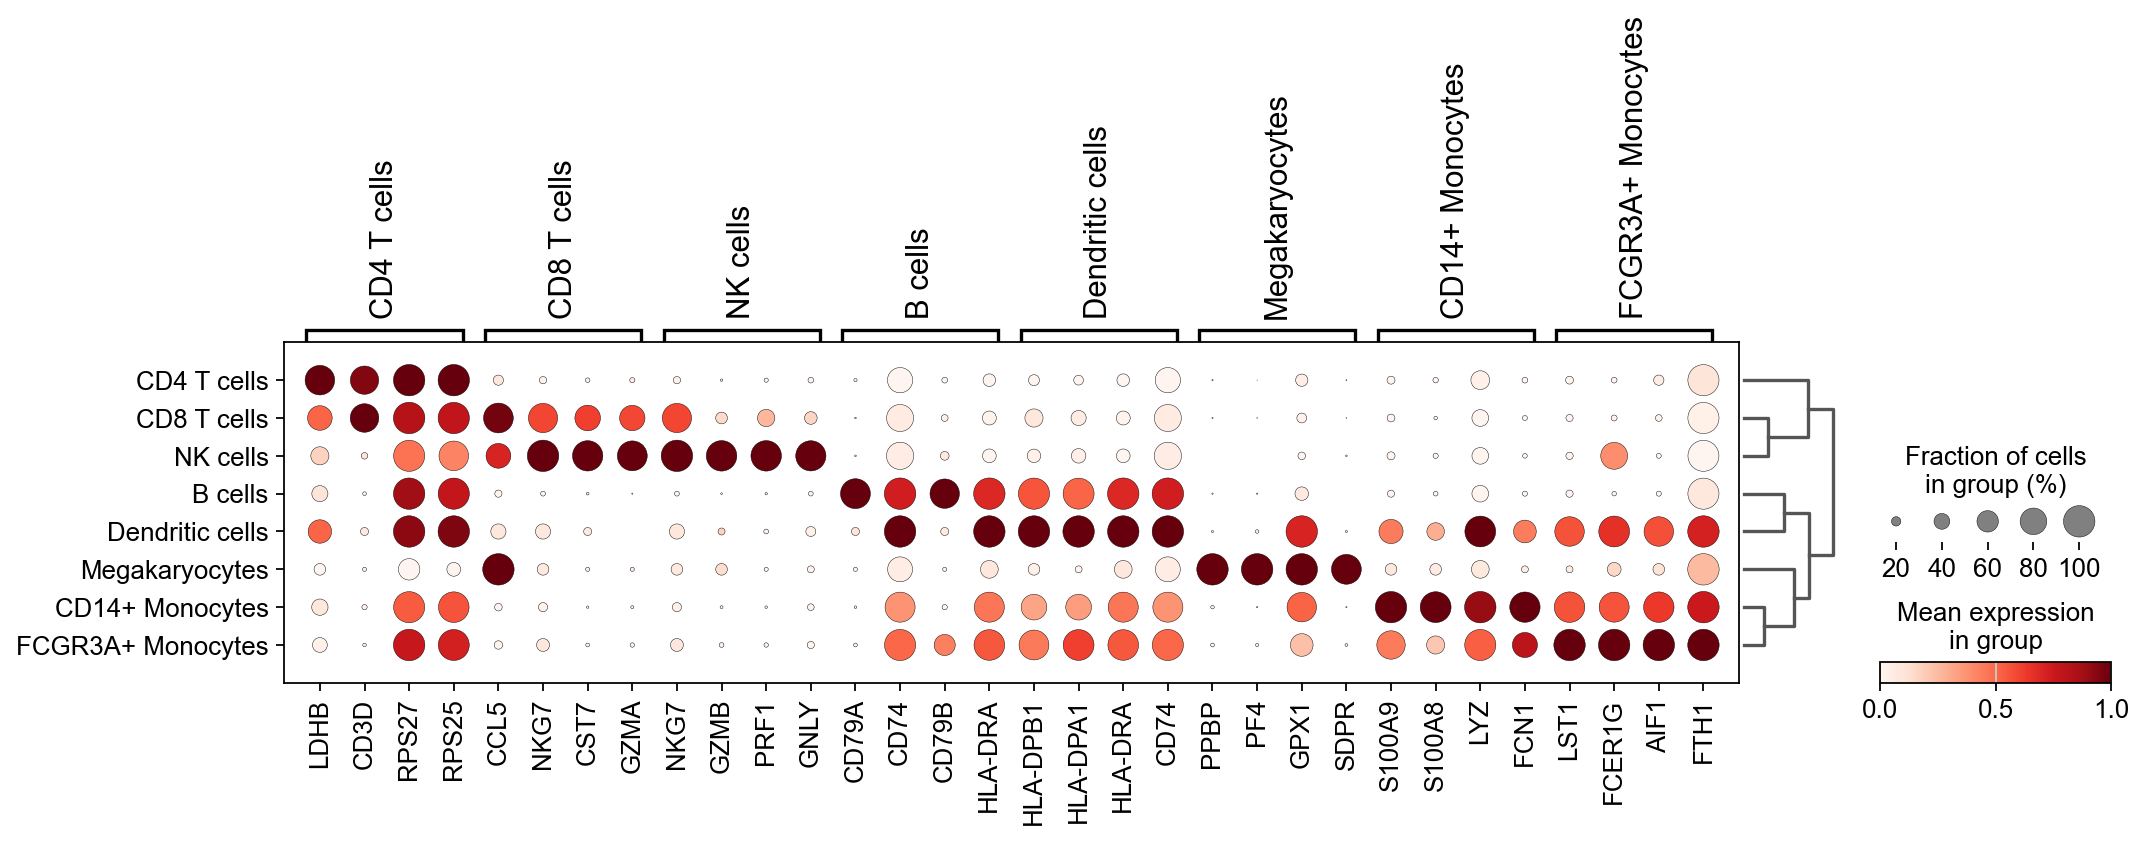

In [3]:
# Dotplot: expression level (color) and fraction of cells expressing the gene (dot size)
# This is one of the most information-dense DE visualizations
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=4,
    groupby='louvain',
    standard_scale='var'  # scale each gene to [0,1] for visual comparison
)

## Reading the Dotplot

- **Color intensity** — average expression level in that cell type
- **Dot size** — fraction of cells in that cluster that express the gene at all

A good marker gene has both: high expression AND high fraction. A gene that is highly expressed but only in 20% of cells is a weaker marker than one expressed at moderate levels in 90% of cells.

In [4]:
# Extract results for one cell type as a DataFrame
de_df = sc.get.rank_genes_groups_df(adata, group='CD14+ Monocytes')
de_df.head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,S100A9,33.336693,6.293413,1.135787e-243,1.557618e-239
1,S100A8,32.919678,6.558624,1.149491e-237,7.882058e-234
2,LYZ,32.667141,5.377507,4.575490e-234,2.091609e-230
3,FCN1,30.117847,4.582602,2.829396e-199,9.700583e-196
4,FTL,29.972912,3.388706,2.212951e-197,6.069683e-194
5,TYROBP,29.874357,4.324084,4.238340e-196,9.687433e-193
6,CST3,29.702953,4.511782,7.033174e-194,1.377899e-190
7,LGALS2,29.646702,5.506694,3.740393e-193,6.411969e-190
8,FTH1,29.033569,2.767588,2.481194e-185,3.402710e-182
9,LGALS1,28.091974,3.496107,1.227762e-173,1.530684e-170


## Column meanings

- `names` — gene name
- `scores` — the test statistic (higher = more specific to this group)
- `logfoldchanges` — log2 fold change vs. the rest of the dataset
- `pvals` — raw p-value
- `pvals_adj` — Benjamini-Hochberg adjusted p-value (use this for significance calls)

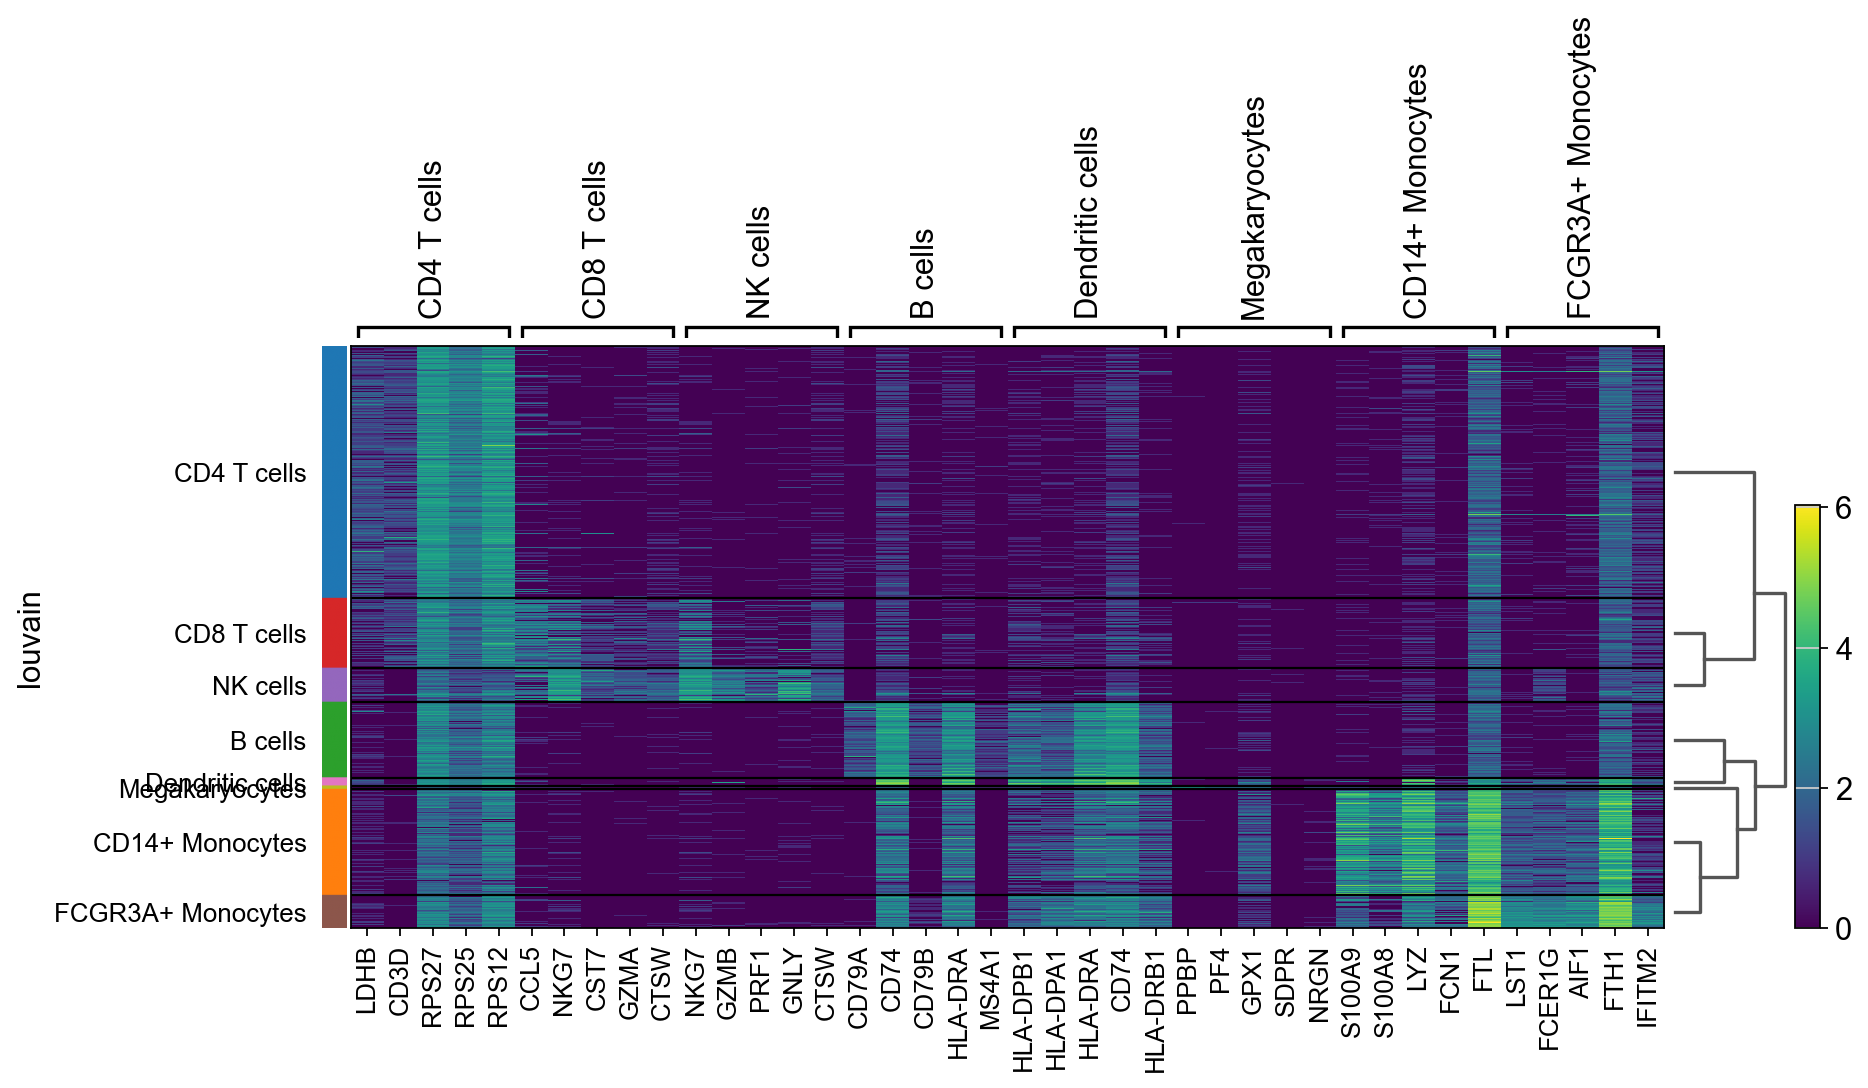

In [5]:
# Heatmap of top marker genes per cell type
# Cells are grouped by cell type; genes are the top markers for each group
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=5,
    groupby='louvain',
    show_gene_labels=True,
    figsize=(12, 5)
)

---
# 4. Condition-Level DE
---

Marker genes tell us what defines each cell type. Condition DE asks a different question: **within a known cell type, what changes between experimental groups?**

This is the typical question in disease studies, drug treatment experiments, or any comparison across biological states.

## Setup

We subset to one cell type (CD14+ Monocytes) and simulate a condition label. Since we are assigning conditions randomly, we expect to find **no real DE genes** — this is intentional. It demonstrates what a null result looks like, and is an important sanity check for any real analysis.

In [6]:
# Subset to one cell type
mono = adata[adata.obs['louvain'] == 'CD14+ Monocytes'].copy()
print(f"Monocytes: {mono.n_obs} cells")

# Assign random condition labels
# In a real experiment these would reflect biology (treated vs untreated, etc.)
np.random.seed(42)
mono.obs['condition'] = np.random.choice(['control', 'treatment'], size=mono.n_obs)
print(mono.obs['condition'].value_counts())

Monocytes: 480 cells
condition
treatment    247
control      233
Name: count, dtype: int64


In [7]:
# Run DE between conditions
# reference='control' means positive LFC = higher in treatment
sc.tl.rank_genes_groups(
    mono,
    groupby='condition',
    method='wilcoxon',
    reference='control'
)

cond_de = sc.get.rank_genes_groups_df(mono, group='treatment')
print(f"Significant genes (padj < 0.05, |LFC| > 0.5): "
      f"{((cond_de['pvals_adj'] < 0.05) & (cond_de['logfoldchanges'].abs() > 0.5)).sum()}")
cond_de.head(10)

Significant genes (padj < 0.05, |LFC| > 0.5): 0


,names,scores,logfoldchanges,pvals,pvals_adj
0,ATP5G2,2.998695,0.312557,0.002711,1.0
1,PRR13,2.925613,0.555535,0.003438,1.0
2,OXA1L,2.576001,0.808854,0.009995,1.0
3,LSP1,2.473948,0.420435,0.013363,1.0
4,EVL,2.341939,0.879939,0.019184,1.0
5,TCIRG1,2.175034,1.213186,0.029628,1.0
6,UBE2L6,2.151660,0.452806,0.031424,1.0
7,FKBP1A,2.087795,0.321735,0.036816,1.0
8,ATRAID,2.071006,0.644657,0.038358,1.0
9,RPL31,2.051254,0.196601,0.040242,1.0


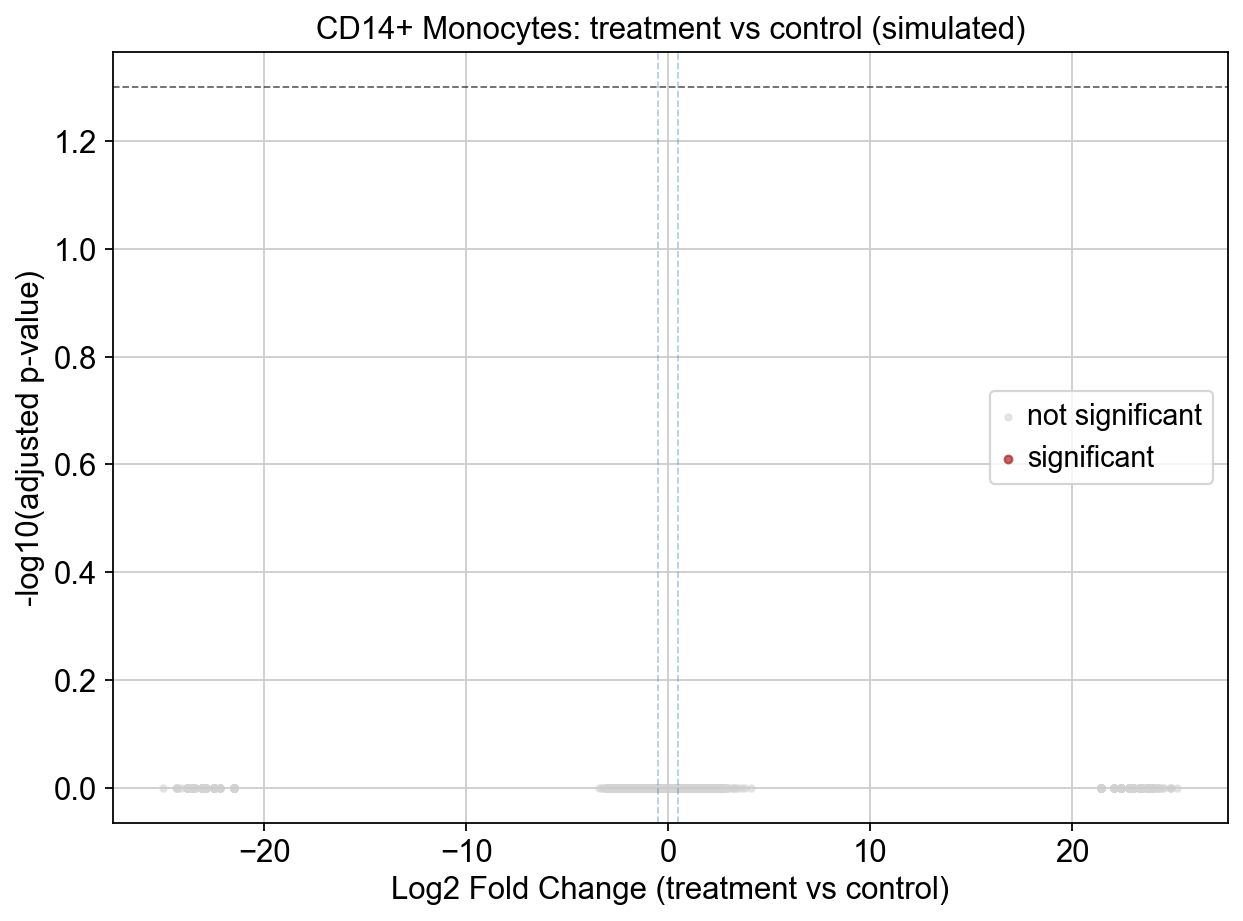


Expected result: no significant genes, because conditions are randomly assigned.
In a real experiment with a genuine effect, you would see points in the upper-left and upper-right corners.


In [8]:
# Volcano plot: LFC on x-axis, significance on y-axis
# Significant genes (both LFC and p-value thresholds met) appear in the upper corners
lfc = cond_de['logfoldchanges']
padj = cond_de['pvals_adj'].clip(lower=1e-300)  # prevent log(0)

sig_mask = (padj < 0.05) & (lfc.abs() > 0.5)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(lfc[~sig_mask], -np.log10(padj[~sig_mask]),
           color='lightgray', alpha=0.5, s=8, label='not significant')
ax.scatter(lfc[sig_mask], -np.log10(padj[sig_mask]),
           color='firebrick', alpha=0.7, s=12, label='significant')

ax.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(0.5, color='steelblue', linestyle='--', linewidth=0.8, alpha=0.4)
ax.axvline(-0.5, color='steelblue', linestyle='--', linewidth=0.8, alpha=0.4)

ax.set_xlabel('Log2 Fold Change (treatment vs control)')
ax.set_ylabel('-log10(adjusted p-value)')
ax.set_title('CD14+ Monocytes: treatment vs control (simulated)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nExpected result: no significant genes, because conditions are randomly assigned.")
print("In a real experiment with a genuine effect, you would see points in the upper-left and upper-right corners.")

---
# 5. Pseudobulk DE
---

## Why standard single-cell DE can mislead

When we run a Wilcoxon test treating each cell as an independent observation, we are implicitly assuming that 400 monocytes from one donor give 400 independent data points. They do not. Cells from the same donor are correlated — they come from the same biological individual with the same genome, environment, and condition.

This inflates the effective sample size and produces far too many false positives, especially for subtle effects.

## The pseudobulk solution

Aggregate cells to the donor level first. Then run statistics with n = number of donors — which is the real unit of replication. This is the approach used in most current best-practice guidelines for scRNA DE.

**Requirement:** multiple donors or biological replicates per condition.

## Demonstration

We simulate 6 pseudo-donors (3 per condition) by randomly assigning cells. Since both donors and conditions are random, we again expect a null result — the point is to show the mechanics of the approach.

In [9]:
# Extract log-normalized expression across all genes (from .raw, before HVG subsetting)
raw_adata = adata.raw.to_adata()
mono_full = raw_adata[adata.obs['louvain'] == 'CD14+ Monocytes'].copy()

# Simulate 6 donors, 3 per condition
np.random.seed(0)
donors = ['D1', 'D2', 'D3', 'D4', 'D5', 'D6']
condition_map = {'D1': 'control', 'D2': 'control', 'D3': 'control',
                 'D4': 'treatment', 'D5': 'treatment', 'D6': 'treatment'}
mono_full.obs['donor'] = np.random.choice(donors, size=mono_full.n_obs)
mono_full.obs['condition'] = mono_full.obs['donor'].map(condition_map)

# Aggregate: mean expression per donor (pseudobulk)
pb = {}
for d in donors:
    mask = mono_full.obs['donor'] == d
    X = mono_full[mask].X
    if sp.issparse(X):
        X = X.toarray()
    pb[d] = X.mean(axis=0)

pb_df = pd.DataFrame(pb, index=mono_full.var_names).T
pb_df['condition'] = [condition_map[d] for d in pb_df.index]

print(f"Pseudobulk matrix: {pb_df.shape[0]} donors x {pb_df.shape[1]-1} genes")
print(pb_df[['condition']].join(pb_df.iloc[:, :3]))

Pseudobulk matrix: 6 donors x 13714 genes
index  condition  AL627309.1  AP006222.2  RP11-206L10.2
D1       control    0.007788    0.000000            0.0
D2       control    0.018004    0.009002            0.0
D3       control    0.000000    0.000000            0.0
D4     treatment    0.014441    0.000000            0.0
D5     treatment    0.000000    0.000000            0.0
D6     treatment    0.009242    0.000000            0.0


In [10]:
# T-test between conditions across donors, one gene at a time
ctrl = pb_df[pb_df['condition'] == 'control'].drop('condition', axis=1)
treat = pb_df[pb_df['condition'] == 'treatment'].drop('condition', axis=1)

results = []
for gene in ctrl.columns:
    t, p = stats.ttest_ind(treat[gene].values, ctrl[gene].values)
    lfc = treat[gene].mean() - ctrl[gene].mean()  # difference in log space ≈ log2FC
    results.append({'gene': gene, 'log2fc': lfc, 'pval': p})

pb_results = pd.DataFrame(results)
# Bonferroni correction (conservative; Benjamini-Hochberg is more common in practice)
pb_results['pval_adj'] = (pb_results['pval'] * len(pb_results)).clip(upper=1.0)
pb_results = pb_results.sort_values('pval')

n_sig = ((pb_results['pval_adj'] < 0.05) & (pb_results['log2fc'].abs() > 0.5)).sum()
print(f"Significant genes: {n_sig} (expected ~0 with random conditions)")
pb_results.head(10)

Significant genes: 0 (expected ~0 with random conditions)


,gene,log2fc,pval,pval_adj
12048,PFDN4,0.009815,0.000099,1.0
2717,C3orf38,0.025842,0.000118,1.0
5816,SLC25A43,-0.017795,0.000131,1.0
11857,CSRP2BP,-0.008897,0.000131,1.0
9257,RP11-66N24.3,-0.008897,0.000131,1.0
7636,TCP11L1,-0.008897,0.000131,1.0
11998,TNNC2,-0.008897,0.000131,1.0
11580,RAB40B,-0.008897,0.000131,1.0
3238,WDR19,-0.008897,0.000131,1.0
8510,LARP4,-0.008897,0.000131,1.0


## What this tells us

With n=3 donors per condition, this test has very limited statistical power. In a real experiment you would typically want at least 4-6 donors per group to detect moderate effect sizes.

The Bonferroni correction used here is conservative. Benjamini-Hochberg (FDR correction) is more commonly used in practice and is less likely to miss real effects.

For production-grade pseudobulk DE, tools like DESeq2 (via `pydeseq2` in Python) handle normalization, dispersion estimation, and size factors more rigorously than a plain t-test. The approach here illustrates the principle; the implementation would differ in a real analysis.

---
# 6. Summary
---

We covered three levels of DE analysis:

1. **Marker genes** — one-vs-rest across all clusters; identifies what defines each cell type
2. **Condition DE** — within a cell type; identifies what changes between biological groups
3. **Pseudobulk DE** — the statistically honest version; treats donors as the unit of replication

## Key takeaways

- Always report both effect size (LFC) and corrected significance (adjusted p-value)
- A null result (no significant genes with random conditions) is a valid and informative sanity check
- Single-cell-level DE inflates sample size; use pseudobulk when you have multiple donors
- The choice of method (Wilcoxon, t-test, DESeq2) matters less than having proper biological replication